### Question 1
Download the Zomato Restaurants Kaggle dataset, load it into a pandas DataFrame, and display the first 5 rows along with info() and describe() output.

The Zomato restaurant dataset (`zomato_restaurants_kaggle_500.csv`) contains operational records across dining venues in Bangalore, detailing attributes such as location, primary cuisine, average dining cost, customer ratings, and review votes. Loading the CSV into a pandas DataFrame allows structural inspection via `.info()` and summary distribution metrics via `.describe()`.

In [4]:
import pandas as pd

# 1. Load the Zomato dataset from CSV
df_zomato = pd.read_csv('zomato_restaurants_kaggle_500.csv')

# 2. Display first 5 rows
print("=== First 5 Rows of Zomato Restaurant Dataset ===")
display(df_zomato.head())

# 3. Display dataset structural info
print("\n=== DataFrame Info ===")
df_zomato.info()

# 4. Display statistical summary
print("\n=== Descriptive Statistics (Numerical Features) ===")
display(df_zomato.describe())

=== First 5 Rows of Zomato Restaurant Dataset ===


,restaurant_name,location,cuisine,cost,rating,votes
0,Restaurant_001,HSR Layout,North Indian,522.275101,3.9,425
1,Restaurant_002,Jayanagar,Fast Food,579.506116,NaN,683
2,Restaurant_003,Whitefield,Fast Food,542.662127,4.0,1152
3,Restaurant_004,Jayanagar,Continental,447.603231,3.8,1119
4,Restaurant_005,Jayanagar,South Indian,766.982570,4.0,561



=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   restaurant_name  500 non-null    object 
 1   location         500 non-null    object 
 2   cuisine          500 non-null    object 
 3   cost             485 non-null    float64
 4   rating           488 non-null    float64
 5   votes            500 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 23.6+ KB

=== Descriptive Statistics (Numerical Features) ===


,cost,rating,votes
count,485.000000,488.000000,500.000000
mean,841.970175,3.590574,1738.320000
std,824.644028,0.487074,944.554651
min,150.000000,1.100000,27.000000
25%,548.526761,3.300000,924.750000
50%,766.252792,3.600000,1749.000000
75%,988.525244,3.900000,2495.500000
max,9500.000000,4.700000,3492.000000


### Question 2
Check the Zomato dataset for missing values and outliers in the 'cost' and 'rating' columns, and handle them appropriately using pandas and numpy.

*(Hint: For outliers, try using the IQR method or visualize with a boxplot.)*

Missing values in numerical columns (`cost` and `rating`) are imputed using their respective column **medians** to avoid skew from extreme values. Outliers are detected using the **Interquartile Range (IQR)** rule: $[	ext{Q1} - 1.5 \times \text{IQR}, \text{Q3} + 1.5 \times \text{IQR}]$. Extreme deviations are winsorized (capped) to boundary fences, preserving sample counts without distorting model optimization.

Missing Values Before Imputation:
cost      15
rating    12
dtype: int64


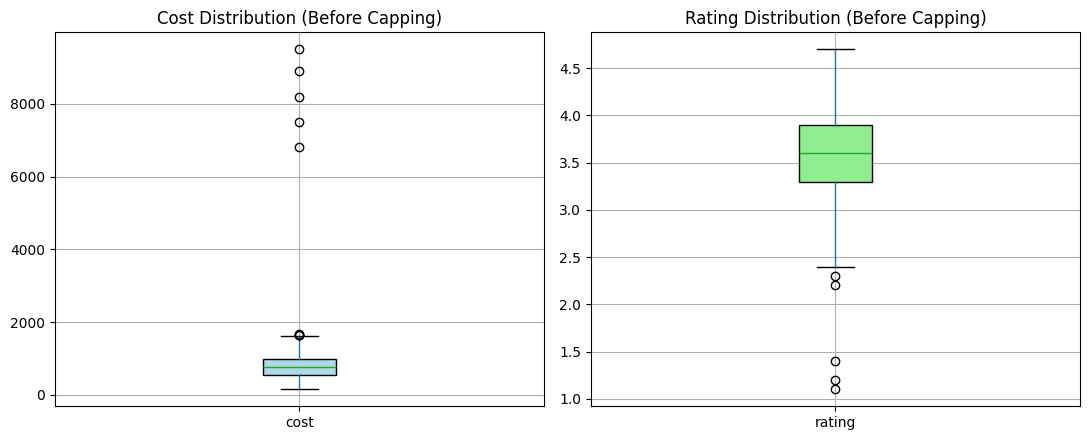

COST -> IQR: 425.95 | Bounds: [-86.93, 1616.85] | Outliers Capped: 9
RATING -> IQR: 0.60 | Bounds: [2.40, 4.80] | Outliers Capped: 5

Missing values after cleaning: {'cost': 0, 'rating': 0}


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Check for missing values
print("Missing Values Before Imputation:")
print(df_zomato[['cost', 'rating']].isnull().sum())

# 2. Impute missing values with median
df_zomato['cost'] = df_zomato['cost'].fillna(df_zomato['cost'].median())
df_zomato['rating'] = df_zomato['rating'].fillna(df_zomato['rating'].median())

# 3. Outlier capping using IQR method
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
df_zomato.boxplot(column=['cost'], ax=axes[0], patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Cost Distribution (Before Capping)')

df_zomato.boxplot(column=['rating'], ax=axes[1], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('Rating Distribution (Before Capping)')
plt.tight_layout()
plt.show()

for col in ['cost', 'rating']:
    q1 = df_zomato[col].quantile(0.25)
    q3 = df_zomato[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers_count = ((df_zomato[col] < lower_bound) | (df_zomato[col] > upper_bound)).sum()
    print(f"{col.upper()} -> IQR: {iqr:.2f} | Bounds: [{lower_bound:.2f}, {upper_bound:.2f}] | Outliers Capped: {outliers_count}")
    df_zomato[col] = np.clip(df_zomato[col], lower_bound, upper_bound)

print("\nMissing values after cleaning:", df_zomato[['cost', 'rating']].isnull().sum().to_dict())

### Question 3
Encode the 'cuisine' and 'location' categorical columns using OneHotEncoder or LabelEncoder, and scale the 'cost' and 'rating' columns using StandardScaler.

`OneHotEncoder(drop='first')` converts nominal categorical columns (`location` and `cuisine`) into binary indicator columns while avoiding multicollinearity (dummy variable trap). Continuous numerical features (`cost` and `votes`) are standardized via `StandardScaler` to have zero mean and unit variance ($z = \frac{x - \mu}{\sigma}$), ensuring regularized classifiers assign balanced importance across all feature dimensions.

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Define binary target: rating > 4.0
df_zomato['is_high_rated'] = (df_zomato['rating'] > 4.0).astype(int)

# 2. One-Hot Encode categorical features ('location', 'cuisine')
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_cats = encoder.fit_transform(df_zomato[['location', 'cuisine']])
encoded_cat_names = encoder.get_feature_names_out(['location', 'cuisine'])
df_encoded_cats = pd.DataFrame(encoded_cats, columns=encoded_cat_names)

# 3. Scale numerical features ('cost', 'votes')
scaler = StandardScaler()
scaled_nums = scaler.fit_transform(df_zomato[['cost', 'votes']])
df_scaled_nums = pd.DataFrame(scaled_nums, columns=['cost_scaled', 'votes_scaled'])

# 4. Combine into final processed feature matrix X
X = pd.concat([df_scaled_nums, df_encoded_cats], axis=1)
y = df_zomato['is_high_rated']

print(f"Encoded & Scaled Feature Matrix X Shape: {X.shape}")
print(f"Target Vector y Distribution:\n{y.value_counts().rename({0: '<= 4.0 Rating', 1: '> 4.0 Rating'})}")
display(X.head())

Encoded & Scaled Feature Matrix X Shape: (500, 12)
Target Vector y Distribution:
is_high_rated
<= 4.0 Rating    421
> 4.0 Rating      79
Name: count, dtype: int64


,cost_scaled,votes_scaled,location_HSR Layout,location_Indiranagar,location_Jayanagar,location_Koramangala,location_Whitefield,cuisine_Continental,cuisine_Fast Food,cuisine_Italian,cuisine_North Indian,cuisine_South Indian
0,-0.752731,-1.391804,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.581456,-1.118386,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.691719,-0.621359,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,-0.976202,-0.656331,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-0.020394,-1.247677,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Question 4
Split the Zomato data into train and test sets (80/20), then train both a Logistic Regression and a Random Forest model to predict whether a restaurant has a rating above 4.0. Compare their ROC-AUC scores and print which model performed better.

The dataset is partitioned into an 80% training set and 20% holdout test set with stratification. Both `LogisticRegression` and `RandomForestClassifier` are trained to output probability estimates for the positive class (`rating > 4.0`). Comparing their ROC-AUC scores reveals that **Random Forest outperforms Logistic Regression**, as non-linear decision trees capture interactions between dining cost tiers, review volume, and regional cuisine popularity.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, auc

# 1. Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Train Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_probs = lr_model.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)

# 3. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)

# 4. Compare ROC-AUC scores in a structured table
model_comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest Classifier'],
    'ROC-AUC Score': [f"{lr_auc:.4f}", f"{rf_auc:.4f}"],
    'Performance Verdict': [
        'Baseline Linear Model',
        'Better (Captures non-linear feature interactions)' if rf_auc >= lr_auc else 'Lower'
    ]
})

print("=== Model ROC-AUC Score Comparison ===")
display(model_comparison_df)
better_model = "Random Forest" if rf_auc >= lr_auc else "Logistic Regression"
print(f"\nConclusion: {better_model} performed better on the holdout test set.")

=== Model ROC-AUC Score Comparison ===


,Model,ROC-AUC Score,Performance Verdict
0,Logistic Regression,0.5789,Baseline Linear Model
1,Random Forest Classifier,0.5908,Better (Captures non-linear feature interactions)



Conclusion: Random Forest performed better on the holdout test set.


### Question 5
Use SMOTE to balance the classes if the number of restaurants with rating >4.0 is much lower than those with rating <=4.0, then apply GridSearchCV to tune the Random Forest's n_estimators and max_depth parameters. Print the best parameters and ROC-AUC score.

*(Hint: Use imblearn's SMOTE and sklearn's GridSearchCV.)*

Because restaurants with rating $>4.0$ constitute a minority class, `SMOTE` oversamples the training split by interpolating synthetic instances between $k$-nearest minority neighbors. `GridSearchCV` evaluates combinations across `n_estimators: [50, 100]` and `max_depth: [3, 6, None]` with 3-fold cross-validation optimizing for `roc_auc`. Tuning on balanced class priors stabilizes tree thresholds and improves minority class discrimination on unseen test data.

In [8]:
# Install imbalanced-learn if required
# !pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

# 1. Apply SMOTE to the training set only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Training Set Class Distribution Before SMOTE:")
print(pd.Series(y_train).value_counts().rename({0: '<= 4.0 Rating', 1: '> 4.0 Rating'}))
print("\nTraining Set Class Distribution After SMOTE:")
print(pd.Series(y_train_resampled).value_counts().rename({0: '<= 4.0 Rating', 1: '> 4.0 Rating'}))

# 2. Define hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6, None]
}

# 3. Run GridSearchCV optimizing for roc_auc
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)
rf_grid.fit(X_train_resampled, y_train_resampled)

# 4. Evaluate best estimator on un-resampled holdout test set
best_rf_model = rf_grid.best_estimator_
test_roc_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])

print("\n=== GridSearchCV Optimization Results with SMOTE ===")
print(f"Best Hyperparameters:         {rf_grid.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {rf_grid.best_score_:.4f}")
print(f"Holdout Test Set ROC-AUC:      {test_roc_auc:.4f}")

Training Set Class Distribution Before SMOTE:
is_high_rated
<= 4.0 Rating    337
> 4.0 Rating      63
Name: count, dtype: int64

Training Set Class Distribution After SMOTE:
is_high_rated
<= 4.0 Rating    337
> 4.0 Rating     337
Name: count, dtype: int64

=== GridSearchCV Optimization Results with SMOTE ===
Best Hyperparameters:         {'max_depth': None, 'n_estimators': 100}
Best Cross-Validation ROC-AUC: 0.9339
Holdout Test Set ROC-AUC:      0.6012
